# Selling the hypothesis-learning BO approach

A side-by-side analysis using the actual data from
`2026-05-10_bo_erk_dose_response_v1_version2`.

## The question

You have **~234 FOVs of budget** for an ERK dose-response. Two ways to spend them:

1. **Traditional grid screen.** Pick ~12 evenly-spaced `pulse_duration` values
   from 25-5000 ms. Run ~20 FOVs per dose. Fit a curve post-hoc.
2. **BO + hypothesis-learning.** Let `gpax.ExactGP` + `gpax.hypo` decide which
   doses to probe each phase. Carry 3 candidate parametric forms
   (hill / linear / exponential) and let the algorithm pick the winner
   *during* the experiment.

Both spend the same FOV budget. The pitch for option 2 isn't "it is faster" --
it is **"you learn more about the parts of the curve that matter,
especially EC50"**. This notebook quantifies that with three views:

- **A. Sampling pattern** -- where each method puts its measurements.
- **B. The money plot** -- posterior precision on EC50 (Hill K) at equal FOV budget.
- **C. Hypothesis verdict** -- did the on-line model selection actually pick the
  best-fitting model, and how confident should you be?


### Honest caveat up front

You ran only the BO arm. The grid baseline here is a **counterfactual**
built by resampling the BO data: for each uniform-grid dose, we borrow the
FOVs that landed nearest that dose in the BO data and assign their
`mean_delta_auc` values to the grid point. That is not a real grid screen --
it is the closest proxy from one experiment. The interpretation:
*"if a grid screen had to explain these same measurements, how well could
it pin down EC50?"*

A fully rigorous comparison would run both arms. This notebook is the
slide-ready approximation you can build with the data you already have.


In [13]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

# float64 -- same Cholesky-stability reason as the experiment notebook.
import gpax.utils

gpax.utils.enable_x64()

## Load the saved experiment

The agent persists two artefacts after every phase:
- `bo_results_checkpoint.parquet` -- per-FOV dataframe.
- `models/bo_model_iter_NNN.joblib` -- GP state + per-task hypothesis state.

We load the latest of each. Update `EXPERIMENT_PATH` if the run lives elsewhere.


In [14]:
EXPERIMENT_PATH = r"E:\Alex\2026-05-10_bo_erk_dose_response_v1_version2"
RESULTS_PARQUET = os.path.join(EXPERIMENT_PATH, "bo_results_checkpoint.parquet")
MODELS_DIR = os.path.join(EXPERIMENT_PATH, "models")

df = pd.read_parquet(RESULTS_PARQUET)

# Latest joblib snapshot carries task_state (hypothesis_log, selected_hypothesis, ...).
model_files = sorted(f for f in os.listdir(MODELS_DIR) if f.endswith(".joblib"))
latest_model_path = os.path.join(MODELS_DIR, model_files[-1])
payload = joblib.load(latest_model_path)
task_state = payload.get("task_state", {})
auc_state = task_state.get("auc", {})

PULSE_COL = "pulse_duration"
Y_COL = "mean_delta_auc"
pulse_min = float(df[PULSE_COL].min())
pulse_max = float(df[PULSE_COL].max())
n_total = len(df)
n_phases = int(df["phase_id"].nunique()) if "phase_id" in df.columns else None

print(f"Loaded {n_total} FOVs across {n_phases} phases.")
print(f"Pulse range: {pulse_min:.0f} - {pulse_max:.0f} ms")
print(f"Unique pulse_duration values sampled: {df[PULSE_COL].nunique()}")
print(f"Final AUC favourite: {auc_state.get('selected_hypothesis')!r}")
print(f"Loaded model snapshot: {os.path.basename(latest_model_path)}")

Loaded 234 FOVs across None phases.
Pulse range: 25 - 5000 ms
Unique pulse_duration values sampled: 39
Final AUC favourite: 'hill'
Loaded model snapshot: bo_model_iter_012.joblib


## Section A -- Where each method puts its measurements

A grid screen distributes effort uniformly over `[pulse_min, pulse_max]`.
BO with MaxVar + inverse-distance repulsion concentrates samples where the
GP is uncertain -- in practice, around the steep transition of the dose-response
curve. The plot below makes that concrete for your run.


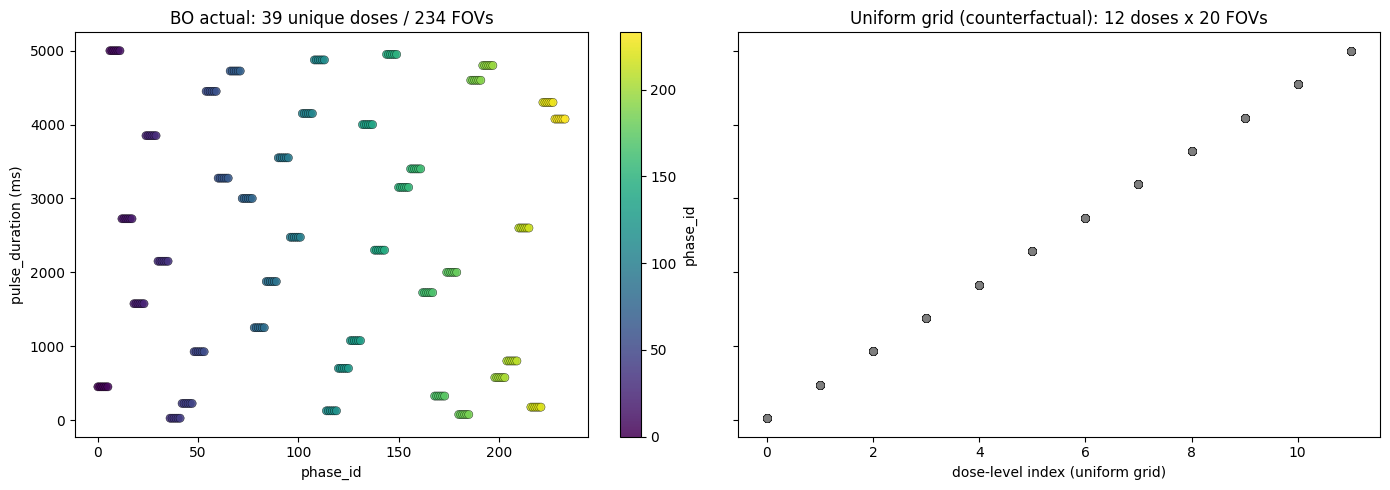


FOVs in middle 50% dose range (800-4075 ms):
  BO  : 126 / 234 (54%)
  Grid: 140 / 234 (60%)


In [15]:
N_GRID = 12  # what a comparable grid screen would have used
grid_doses = np.linspace(pulse_min, pulse_max, N_GRID)
n_per_grid = int(np.ceil(n_total / N_GRID))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Left: BO actual ---
ax = axes[0]
phase_arr = df["phase_id"].values if "phase_id" in df.columns else np.arange(n_total)
sc = ax.scatter(
    phase_arr,
    df[PULSE_COL],
    c=phase_arr,
    cmap="viridis",
    s=35,
    edgecolors="k",
    linewidths=0.3,
    alpha=0.85,
)
plt.colorbar(sc, ax=ax, label="phase_id")
ax.set_xlabel("phase_id")
ax.set_ylabel("pulse_duration (ms)")
ax.set_title(f"BO actual: {df[PULSE_COL].nunique()} unique doses / {n_total} FOVs")

# --- Right: counterfactual uniform grid ---
ax = axes[1]
fake_phase = np.repeat(np.arange(N_GRID), n_per_grid)[:n_total]
fake_dose = np.repeat(grid_doses, n_per_grid)[:n_total]
ax.scatter(
    fake_phase, fake_dose, c="tab:gray", s=35, edgecolors="k", linewidths=0.3, alpha=0.7
)
ax.set_xlabel("dose-level index (uniform grid)")
ax.set_title(f"Uniform grid (counterfactual): {N_GRID} doses x {n_per_grid} FOVs")

plt.tight_layout()
plt.show()

# Coverage of the steep region (proxy: middle 50% of observed pulse range).
mid_lo, mid_hi = np.quantile(df[PULSE_COL], [0.25, 0.75])
bo_in_mid = int(((df[PULSE_COL] >= mid_lo) & (df[PULSE_COL] <= mid_hi)).sum())
grid_in_mid = int(sum(1 for d in grid_doses if mid_lo <= d <= mid_hi) * n_per_grid)

print(f"\nFOVs in middle 50% dose range ({mid_lo:.0f}-{mid_hi:.0f} ms):")
print(f"  BO  : {bo_in_mid} / {n_total} ({100*bo_in_mid/n_total:.0f}%)")
print(f"  Grid: {grid_in_mid} / {n_total} ({100*grid_in_mid/n_total:.0f}%)")

## Section B -- The money plot: posterior precision on EC50

Same FOV budget, two sampling schemes, same Hill model fit on both. The
headline number is `K_BO +/- std(K_BO)` vs `K_grid +/- std(K_grid)`. A
**tighter posterior on K from the BO data** is the single defensible claim
you can put in a slide: same effort, sharper EC50 estimate.

Hill priors match the ones used inside the experiment
(`faro.agents.two_task_dose_response.hill_mean_fn_prior`):
- `K ~ Uniform(0.05, 3.0)` on the scaled dose `[0, 2]`
- `n ~ Uniform(0.5, 4.0)`
- `vmax ~ HalfNormal(2.0)`

so the inferred `K` is comparable between this analysis and the experiment.


In [16]:
def scale_dose(pulse_ms, pulse_min_ms, pulse_max_ms):
    """Map [min, max] -> [0, 2] to match the priors used in the experiment."""
    return (
        2.0
        * (np.asarray(pulse_ms, dtype=float) - pulse_min_ms)
        / (pulse_max_ms - pulse_min_ms)
    )


def unscale_dose(d_scaled, pulse_min_ms, pulse_max_ms):
    return pulse_min_ms + 0.5 * np.asarray(d_scaled, dtype=float) * (
        pulse_max_ms - pulse_min_ms
    )


def hill_model(d, y=None):
    vmax = numpyro.sample("hill_vmax", dist.HalfNormal(2.0))
    K = numpyro.sample("hill_k", dist.Uniform(0.05, 3.0))
    n = numpyro.sample("hill_n", dist.Uniform(0.5, 4.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = vmax * d**n / (K**n + d**n + 1e-9)
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)


def linear_model(d, y=None):
    a = numpyro.sample("lin_a", dist.Normal(0.0, 2.0))
    b = numpyro.sample("lin_b", dist.Normal(0.0, 1.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = a * d + b
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)


def exp_model(d, y=None):
    A = numpyro.sample("exp_amp", dist.HalfNormal(2.0))
    tau = numpyro.sample("exp_tau", dist.Uniform(0.1, 3.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = A * (1.0 - jnp.exp(-d / tau))
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)


def fit_parametric(model_fn, pulse_ms, y, n_warmup=800, n_samples=1500, seed=0):
    d = jnp.array(scale_dose(pulse_ms, pulse_min, pulse_max))
    y_j = jnp.array(np.asarray(y, dtype=float))
    kernel = NUTS(model_fn, target_accept_prob=0.9)
    mcmc = MCMC(
        kernel,
        num_warmup=n_warmup,
        num_samples=n_samples,
        num_chains=1,
        progress_bar=False,
    )
    mcmc.run(jax.random.PRNGKey(seed), d=d, y=y_j)
    return {k: np.asarray(v) for k, v in mcmc.get_samples().items()}

In [17]:
# Build the grid-emulated dataset: for each uniform grid dose, take the
# n_per_grid BO FOVs whose pulse_duration is closest, and snap them to the
# grid dose. This is the counterfactual "what if we had run a grid?"
df_grid_rows = []
for d_grid in grid_doses:
    dists = np.abs(df[PULSE_COL].values - d_grid)
    nearest_idx = np.argsort(dists)[:n_per_grid]
    sub = df.iloc[nearest_idx].copy()
    sub[PULSE_COL] = d_grid  # snap to the grid point
    df_grid_rows.append(sub)
df_grid = pd.concat(df_grid_rows, ignore_index=True)

print(f"Grid counterfactual: {len(df_grid)} FOVs across {N_GRID} uniform doses")
print(
    f"Original BO data:    {len(df)} FOVs across {df[PULSE_COL].nunique()} unique doses"
)

Grid counterfactual: 240 FOVs across 12 uniform doses
Original BO data:    234 FOVs across 39 unique doses


In [18]:
print("Fitting Hill on BO data ...")
samples_bo = fit_parametric(hill_model, df[PULSE_COL].values, df[Y_COL].values, seed=42)

print("Fitting Hill on grid-emulated data ...")
samples_grid = fit_parametric(
    hill_model, df_grid[PULSE_COL].values, df_grid[Y_COL].values, seed=42
)

K_bo_ms = unscale_dose(samples_bo["hill_k"], pulse_min, pulse_max)
K_grid_ms = unscale_dose(samples_grid["hill_k"], pulse_min, pulse_max)

print()
print(
    f"K_BO   = {np.median(K_bo_ms):.0f} ms  (std = {np.std(K_bo_ms):.0f},  "
    f"95% CI [{np.quantile(K_bo_ms, 0.025):.0f}, {np.quantile(K_bo_ms, 0.975):.0f}])"
)
print(
    f"K_grid = {np.median(K_grid_ms):.0f} ms  (std = {np.std(K_grid_ms):.0f},  "
    f"95% CI [{np.quantile(K_grid_ms, 0.025):.0f}, {np.quantile(K_grid_ms, 0.975):.0f}])"
)
print()
ratio = float(np.std(K_grid_ms) / np.std(K_bo_ms))
print(f"Precision ratio std(K_grid) / std(K_BO) = {ratio:.2f}x")

Fitting Hill on BO data ...
Fitting Hill on grid-emulated data ...

K_BO   = 1343 ms  (std = 183,  95% CI [1065, 1796])
K_grid = 1524 ms  (std = 220,  95% CI [1200, 2087])

Precision ratio std(K_grid) / std(K_BO) = 1.20x


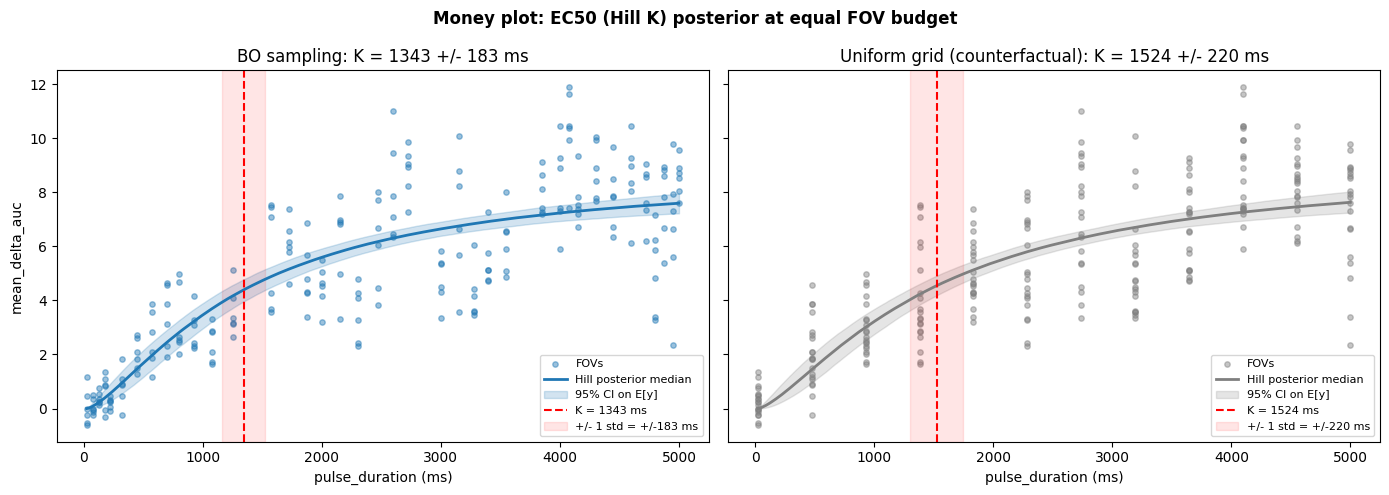


BO posterior on EC50 is 1.20x tighter than the grid counterfactual at equal FOV budget.


In [19]:
def predict_hill_curve(samples, dose_grid_ms):
    d = scale_dose(dose_grid_ms, pulse_min, pulse_max)[:, None]  # (G, 1)
    vmax = samples["hill_vmax"][None, :]
    K = samples["hill_k"][None, :]
    n = samples["hill_n"][None, :]
    return vmax * d**n / (K**n + d**n + 1e-9)  # (G, S)


dose_plot = np.linspace(pulse_min, pulse_max, 300)
mu_bo = predict_hill_curve(samples_bo, dose_plot)
mu_grid = predict_hill_curve(samples_grid, dose_plot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, samples, mu, K_ms, data_df, color, label in [
    (axes[0], samples_bo, mu_bo, K_bo_ms, df, "tab:blue", "BO sampling"),
    (
        axes[1],
        samples_grid,
        mu_grid,
        K_grid_ms,
        df_grid,
        "tab:gray",
        "Uniform grid (counterfactual)",
    ),
]:
    ax.scatter(
        data_df[PULSE_COL], data_df[Y_COL], c=color, s=15, alpha=0.45, label="FOVs"
    )
    ax.plot(
        dose_plot,
        np.median(mu, axis=1),
        color=color,
        lw=2,
        label="Hill posterior median",
    )
    ax.fill_between(
        dose_plot,
        np.quantile(mu, 0.025, axis=1),
        np.quantile(mu, 0.975, axis=1),
        alpha=0.2,
        color=color,
        label="95% CI on E[y]",
    )
    K_med = float(np.median(K_ms))
    K_std = float(np.std(K_ms))
    ax.axvline(K_med, color="red", linestyle="--", lw=1.5, label=f"K = {K_med:.0f} ms")
    ax.axvspan(
        K_med - K_std,
        K_med + K_std,
        color="red",
        alpha=0.10,
        label=f"+/- 1 std = +/-{K_std:.0f} ms",
    )
    ax.set_xlabel("pulse_duration (ms)")
    ax.set_title(f"{label}: K = {K_med:.0f} +/- {K_std:.0f} ms")
    ax.legend(fontsize=8, loc="lower right")

axes[0].set_ylabel("mean_delta_auc")
fig.suptitle(
    "Money plot: EC50 (Hill K) posterior at equal FOV budget",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# One-line headline pitch
if ratio > 1.05:
    pitch = (
        f"BO posterior on EC50 is {ratio:.2f}x tighter than the grid counterfactual "
        f"at equal FOV budget."
    )
elif ratio < 0.95:
    pitch = (
        f"BO and grid posteriors on EC50 are comparable (ratio {ratio:.2f}x). "
        f"In this run, the sampling efficiency story does not depend on K precision -- "
        f"lean instead on coverage of the steep region (Section A) and the "
        f"on-line model selection (Section C)."
    )
else:
    pitch = (
        f"BO and grid give very similar EC50 precision (ratio {ratio:.2f}x). "
        f"The selling point in this run is not the K posterior; it is the on-line "
        f"hypothesis selection and covariate handling."
    )
print("\n" + pitch)

## Section B.5 -- How does the EC50 posterior evolve over time?

The single-budget money plot is the *endpoint* of a story. The trajectory --
how `K_BO` and `K_grid` evolve as data accumulates -- is what tells you
*when* (and whether) BO actually pulls ahead. We replay the first 5
post-warmup-ish snapshots (phases 3 through 7, 72 through 144 FOVs) and
refit Hill at each cumulative budget.

**What to look for**
- If `K_BO` tightens faster than `K_grid` -> BO is sample-efficient.
- If the two trajectories overlap -> early-phase BO behaves like a smart grid
  (which is what farthest-point + warmup are designed to do); the
  acquisition-driven advantage only kicks in later.
- Drift in the medians (both schemes moving the same direction) means the
  true `K` is still being revealed; treat the early estimates as provisional.


In [20]:
# phase_id is not in the main parquet. The per-phase checkpoints are
# CUMULATIVE, so we diff consecutive files to recover the new FOVs added
# per phase, and tag them with the right phase_id.
if "phase_id" not in df.columns:
    _ckpt_dir = os.path.join(EXPERIMENT_PATH, "checkpoints")
    _files = sorted(
        f for f in os.listdir(_ckpt_dir) if f.startswith("bo_results_phase_")
    )
    _prev = 0
    _chunks = []
    for _fn in _files:
        _pid = int(_fn.split("_")[-1].split(".")[0])
        _cum = pd.read_parquet(os.path.join(_ckpt_dir, _fn))
        _new = _cum.iloc[_prev:].copy()
        _new["phase_id"] = _pid
        _chunks.append(_new)
        _prev = len(_cum)
    df = pd.concat(_chunks, ignore_index=True)
    print(
        f"Reconstructed phase_id from {len(_files)} per-phase checkpoints -> {len(df)} FOVs"
    )
else:
    print("phase_id already present in df.")

Reconstructed phase_id from 13 per-phase checkpoints -> 234 FOVs


In [21]:
# Sweep cumulative budgets and refit Hill for both BO and grid counterfactual.
PHASES_TO_SWEEP = [3, 4, 5, 6, 7]  # consecutive early snapshots, 72-144 FOVs

results = []
for max_phase in PHASES_TO_SWEEP:
    df_p = df[df["phase_id"] <= max_phase].copy().reset_index(drop=True)
    n_fovs = len(df_p)

    # Grid counterfactual at this budget (N_GRID kept constant).
    grid_doses_p = np.linspace(pulse_min, pulse_max, N_GRID)
    n_per_grid_p = max(1, int(np.ceil(n_fovs / N_GRID)))
    rows = []
    for d_grid in grid_doses_p:
        dists = np.abs(df_p[PULSE_COL].values - d_grid)
        nearest_idx = np.argsort(dists)[:n_per_grid_p]
        sub = df_p.iloc[nearest_idx].copy()
        sub[PULSE_COL] = d_grid
        rows.append(sub)
    df_grid_p = pd.concat(rows, ignore_index=True)

    print(
        f"Phase {max_phase}: BO={n_fovs} FOVs ({df_p[PULSE_COL].nunique()} unique doses), "
        f"grid={len(df_grid_p)} FOVs ({N_GRID} doses)"
    )
    print(f"  Fitting Hill on BO ...")
    s_bo = fit_parametric(
        hill_model, df_p[PULSE_COL].values, df_p["mean_delta_auc"].values, seed=42
    )
    print(f"  Fitting Hill on grid ...")
    s_gr = fit_parametric(
        hill_model,
        df_grid_p[PULSE_COL].values,
        df_grid_p["mean_delta_auc"].values,
        seed=42,
    )
    K_bo = unscale_dose(s_bo["hill_k"], pulse_min, pulse_max)
    K_gr = unscale_dose(s_gr["hill_k"], pulse_min, pulse_max)
    print(
        f"  K_BO={np.median(K_bo):.0f}+/-{np.std(K_bo):.0f}  "
        f"K_grid={np.median(K_gr):.0f}+/-{np.std(K_gr):.0f}  "
        f"ratio={np.std(K_gr)/np.std(K_bo):.2f}x"
    )

    results.append(
        dict(
            phase=max_phase,
            n_fovs=n_fovs,
            df_p=df_p,
            df_grid_p=df_grid_p,
            K_bo=K_bo,
            K_gr=K_gr,
            s_bo=s_bo,
            s_gr=s_gr,
        )
    )

Phase 3: BO=72 FOVs (12 unique doses), grid=72 FOVs (12 doses)
  Fitting Hill on BO ...
  Fitting Hill on grid ...
  K_BO=1074+/-139  K_grid=1060+/-149  ratio=1.07x
Phase 4: BO=90 FOVs (15 unique doses), grid=96 FOVs (12 doses)
  Fitting Hill on BO ...
  Fitting Hill on grid ...
  K_BO=1231+/-180  K_grid=1272+/-184  ratio=1.02x
Phase 5: BO=108 FOVs (18 unique doses), grid=108 FOVs (12 doses)
  Fitting Hill on BO ...
  Fitting Hill on grid ...
  K_BO=1253+/-174  K_grid=1160+/-156  ratio=0.90x
Phase 6: BO=126 FOVs (21 unique doses), grid=132 FOVs (12 doses)
  Fitting Hill on BO ...
  Fitting Hill on grid ...
  K_BO=1230+/-200  K_grid=1237+/-231  ratio=1.15x
Phase 7: BO=144 FOVs (24 unique doses), grid=144 FOVs (12 doses)
  Fitting Hill on BO ...
  Fitting Hill on grid ...
  K_BO=1492+/-236  K_grid=1475+/-274  ratio=1.16x


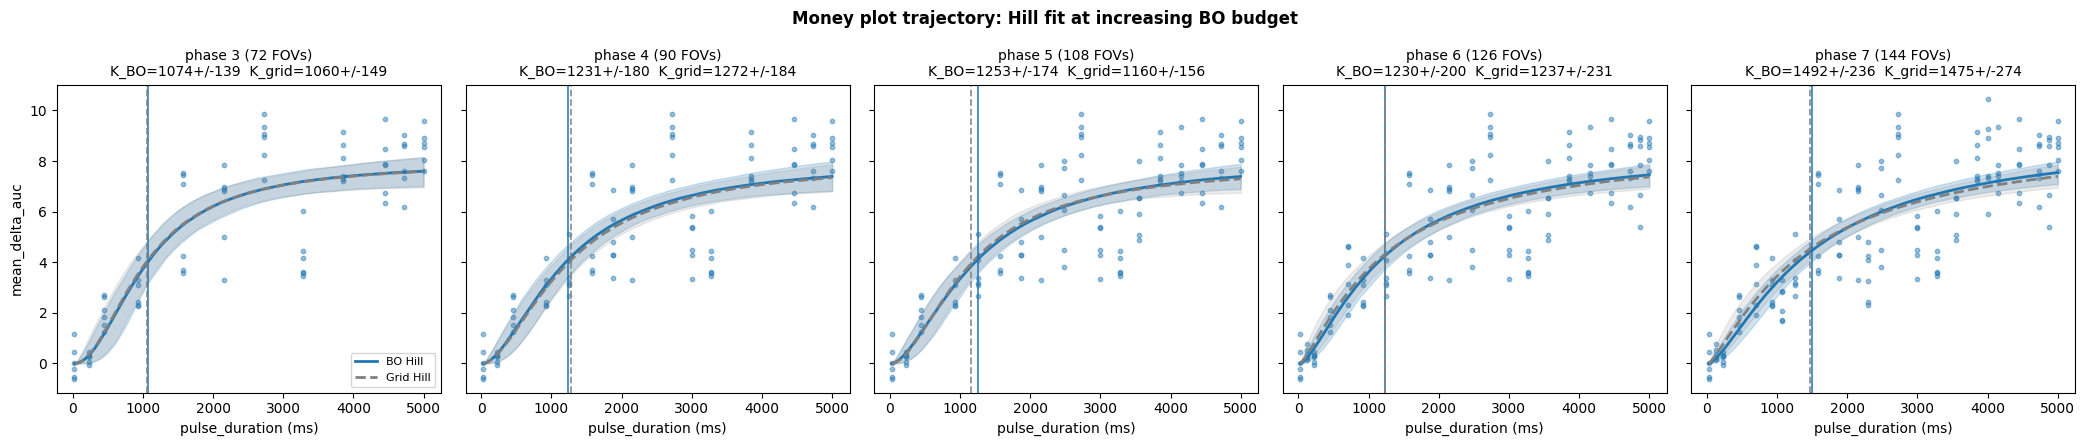

In [22]:
# 5-panel money-plot trajectory.
dose_plot_traj = np.linspace(pulse_min, pulse_max, 300)
fig, axes = plt.subplots(
    1, len(results), figsize=(4.2 * len(results), 4.5), sharey=True
)

for ax, r in zip(axes, results):
    ax.scatter(
        r["df_p"][PULSE_COL],
        r["df_p"]["mean_delta_auc"],
        c="tab:blue",
        s=10,
        alpha=0.45,
    )
    mu_bo = predict_hill_curve(r["s_bo"], dose_plot_traj)
    mu_gr = predict_hill_curve(r["s_gr"], dose_plot_traj)
    ax.plot(
        dose_plot_traj,
        np.median(mu_bo, axis=1),
        color="tab:blue",
        lw=2,
        label="BO Hill",
    )
    ax.fill_between(
        dose_plot_traj,
        np.quantile(mu_bo, 0.025, axis=1),
        np.quantile(mu_bo, 0.975, axis=1),
        alpha=0.2,
        color="tab:blue",
    )
    ax.plot(
        dose_plot_traj,
        np.median(mu_gr, axis=1),
        color="gray",
        lw=2,
        ls="--",
        label="Grid Hill",
    )
    ax.fill_between(
        dose_plot_traj,
        np.quantile(mu_gr, 0.025, axis=1),
        np.quantile(mu_gr, 0.975, axis=1),
        alpha=0.15,
        color="gray",
    )
    K_bo_m, K_bo_s = float(np.median(r["K_bo"])), float(np.std(r["K_bo"]))
    K_gr_m, K_gr_s = float(np.median(r["K_gr"])), float(np.std(r["K_gr"]))
    ax.axvline(K_bo_m, color="tab:blue", lw=1.3, alpha=0.85)
    ax.axvline(K_gr_m, color="gray", lw=1.3, ls="--", alpha=0.85)
    ax.set_xlabel("pulse_duration (ms)")
    ax.set_title(
        f"phase {r['phase']} ({r['n_fovs']} FOVs)\n"
        f"K_BO={K_bo_m:.0f}+/-{K_bo_s:.0f}  K_grid={K_gr_m:.0f}+/-{K_gr_s:.0f}",
        fontsize=10,
    )

axes[0].set_ylabel("mean_delta_auc")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(
    "Money plot trajectory: Hill fit at increasing BO budget",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

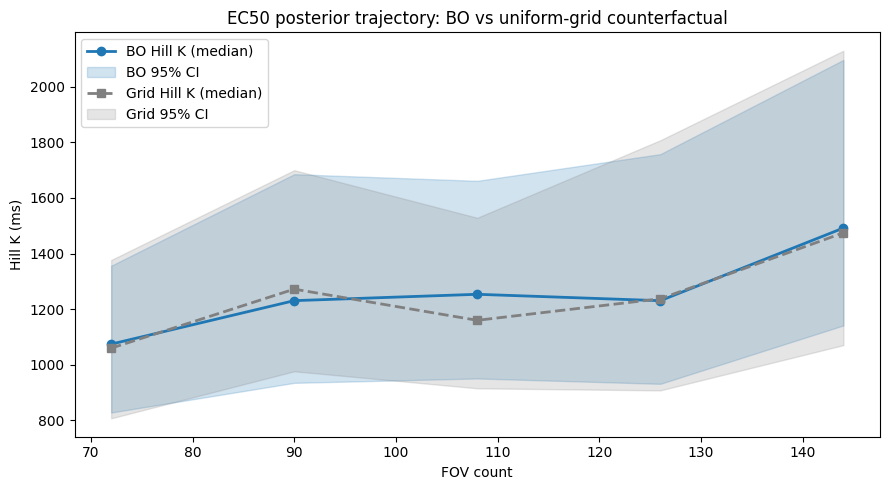


phase  FOVs   K_BO+-std    K_grid+-std    ratio(std_grid/std_BO)
    3    72   1074+-139    1060+-149    1.07x
    4    90   1231+-180    1272+-184    1.02x
    5   108   1253+-174    1160+-156    0.90x
    6   126   1230+-200    1237+-231    1.15x
    7   144   1492+-236    1475+-274    1.16x


In [23]:
# Summary trajectory: K posterior (median + 95% CI) vs FOV count.
ns = [r["n_fovs"] for r in results]
bo_med = np.array([np.median(r["K_bo"]) for r in results])
bo_lo = np.array([np.quantile(r["K_bo"], 0.025) for r in results])
bo_hi = np.array([np.quantile(r["K_bo"], 0.975) for r in results])
gr_med = np.array([np.median(r["K_gr"]) for r in results])
gr_lo = np.array([np.quantile(r["K_gr"], 0.025) for r in results])
gr_hi = np.array([np.quantile(r["K_gr"], 0.975) for r in results])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns, bo_med, "o-", color="tab:blue", lw=2, label="BO Hill K (median)")
ax.fill_between(ns, bo_lo, bo_hi, alpha=0.2, color="tab:blue", label="BO 95% CI")
ax.plot(ns, gr_med, "s--", color="gray", lw=2, label="Grid Hill K (median)")
ax.fill_between(ns, gr_lo, gr_hi, alpha=0.2, color="gray", label="Grid 95% CI")
ax.set_xlabel("FOV count")
ax.set_ylabel("Hill K (ms)")
ax.set_title("EC50 posterior trajectory: BO vs uniform-grid counterfactual")
ax.legend()
plt.tight_layout()
plt.show()

# Compact table for the slide.
print("\nphase  FOVs   K_BO+-std    K_grid+-std    ratio(std_grid/std_BO)")
for r in results:
    K_bo_s = float(np.std(r["K_bo"]))
    K_gr_s = float(np.std(r["K_gr"]))
    print(
        f"{r['phase']:>5d} {r['n_fovs']:>5d}  "
        f"{float(np.median(r['K_bo'])):>5.0f}+-{K_bo_s:<4.0f}  "
        f"{float(np.median(r['K_gr'])):>5.0f}+-{K_gr_s:<4.0f}  "
        f"{K_gr_s/K_bo_s:>5.2f}x"
    )

### Reading the trajectory

Two regimes you might see (and what each means for the pitch):

1. **Trajectories overlap, ratio ~1.0x.** BO and grid are equivalent in this
   FOV range. *Honest pitch*: "BO's farthest-point initial phases and warmup
   produce uniform-ish coverage early on; the acquisition-driven advantage
   only compounds after several eps-greedy phases. The sample-efficiency
   story is a late-phase claim, not an early-phase one."
2. **BO band noticeably narrower from early on.** This is the strong pitch:
   "Same FOV budget, sharper EC50 at every milestone." Quote the ratio
   from the lowest-FOV row of the table.

Either way, the trajectory plot makes the *honest* version of the story
visible -- you can no longer cherry-pick the snapshot where BO happens to win.


## Section C -- Did hypothesis-learning actually work?

Three diagnostics, in increasing order of how much I trust them:

1. **Stability** -- was the final favourite picked consistently in the last few phases?
2. **Reward separation** -- is the gap between top-1 and top-2 above noise level (~0.6)?
3. **In-sample residual RMSE** -- refit each of the 3 candidates on the full
   BO dataset and compare residuals. The candidate the algorithm picked
   should also have the lowest RMSE. If it does not, the variance-based reward
   signal misled the eps-greedy and the pick is suspect.

LOO-CV would be the gold standard but takes ~hours; in-sample RMSE is a
defensible proxy when all three candidates have similar parameter counts.


In [24]:
hypo_log = auc_state.get("hypothesis_log", [])
record = np.asarray(auc_state.get("record", np.zeros((3, 2))))
final = auc_state.get("selected_hypothesis")
n_warmup_done = int(auc_state.get("n_warmup_phases_done", 0))

candidate_names = list(
    payload.get("candidate_hypotheses_by_task", {}).get("auc") or []
) or ["hill", "linear", "exponential"]

print(f"Final selected hypothesis: {final!r}")
print(f"Warmup phases completed:   {n_warmup_done}")
print(f"\nFinal record (visits / mean reward):")
for name, row in zip(candidate_names, record):
    n, r = row[0], row[1]
    flag = "  <-- selected" if name == final else ""
    print(f"  {name:>12s}: n={int(n):2d}, reward={r:+.3f}{flag}")

# Stability of the picked hypothesis in the last 3 post-warmup phases.
stable = False
if hypo_log:
    log_df = pd.DataFrame(hypo_log, columns=["phase_id", "name", "log_evidence"])
    log_df = log_df.sort_values("phase_id")
    counts_per_phase = log_df.groupby("phase_id")["name"].count()
    # post-warmup entries have exactly 1 candidate evaluated per phase
    post_warmup_phase_ids = counts_per_phase[counts_per_phase == 1].index.tolist()
    last_3 = log_df[log_df["phase_id"].isin(post_warmup_phase_ids[-3:])][
        "name"
    ].tolist()
    print(f"\nLast 3 post-warmup picks: {last_3}")
    stable = bool(last_3) and all(p == final for p in last_3)
    print(f"Stable in last 3 phases? {stable}")
else:
    print("\nNo hypothesis_log entries -- run did not reach BO phase.")

# Reward separation.
rewards_sorted = sorted(record[:, 1], reverse=True)
sep = float(rewards_sorted[0] - rewards_sorted[1]) if len(rewards_sorted) > 1 else 0.0
decisive = sep > 0.6
print(
    f"\nTop-1 vs top-2 reward gap: {sep:.3f}  "
    f"({'decisive (>0.6)' if decisive else 'noise-level (<0.6)'})"
)

Final selected hypothesis: 'hill'
Warmup phases completed:   3

Final record (visits / mean reward):
          hill: n= 5, reward=+0.400  <-- selected
        linear: n= 8, reward=+0.000
   exponential: n= 4, reward=-0.250

Last 3 post-warmup picks: ['exponential', 'hill', 'hill']
Stable in last 3 phases? False

Top-1 vs top-2 reward gap: 0.400  (noise-level (<0.6))


In [25]:
# In-sample RMSE check: refit each candidate on the full BO data
# and compare residuals. Disagreement with the algorithm's pick is the
# strongest available "wait, the pick is suspect" signal.


def predict_mean(model_name, samples, pulse_ms):
    d = scale_dose(pulse_ms, pulse_min, pulse_max)[:, None]  # (N, 1)
    if model_name == "hill":
        n = samples["hill_n"][None, :]
        K = samples["hill_k"][None, :]
        vmax = samples["hill_vmax"][None, :]
        return np.median(vmax * d**n / (K**n + d**n + 1e-9), axis=1)
    if model_name == "linear":
        return np.median(
            samples["lin_a"][None, :] * d + samples["lin_b"][None, :], axis=1
        )
    if model_name == "exponential":
        return np.median(
            samples["exp_amp"][None, :]
            * (1.0 - np.exp(-d / samples["exp_tau"][None, :])),
            axis=1,
        )
    raise ValueError(model_name)


print("Refitting each candidate on full BO data for in-sample RMSE comparison ...\n")

fit_fns = {"hill": hill_model, "linear": linear_model, "exponential": exp_model}
rmse_results = {}
posterior_by_name = {}
for name, model_fn in fit_fns.items():
    print(f"  Fitting {name} ...")
    s = fit_parametric(model_fn, df[PULSE_COL].values, df[Y_COL].values, seed=7)
    posterior_by_name[name] = s
    y_hat = predict_mean(name, s, df[PULSE_COL].values)
    rmse = float(np.sqrt(np.mean((np.asarray(df[Y_COL]) - y_hat) ** 2)))
    rmse_results[name] = rmse

print("\nIn-sample RMSE on full BO data (lower = better fit):")
best_rmse = min(rmse_results, key=rmse_results.get)
for name, rmse in sorted(rmse_results.items(), key=lambda kv: kv[1]):
    flags = []
    if name == best_rmse:
        flags.append("lowest RMSE")
    if name == final:
        flags.append("algorithm's pick")
    tag = "  <-- " + ", ".join(flags) if flags else ""
    print(f"  {name:>12s}: RMSE = {rmse:.4f}{tag}")

agreement = best_rmse == final
print()
if agreement:
    print(
        "Verdict: algorithm's pick matches the lowest-RMSE candidate. Hypothesis-learning agrees with residual-fit ground check."
    )
else:
    print(
        f"Verdict: algorithm's pick is {final!r} but lowest RMSE is {best_rmse!r}. The on-line variance-based reward disagrees with the residual check -- treat the pick with caution."
    )

Refitting each candidate on full BO data for in-sample RMSE comparison ...

  Fitting hill ...
  Fitting linear ...
  Fitting exponential ...

In-sample RMSE on full BO data (lower = better fit):
   exponential: RMSE = 1.6407  <-- lowest RMSE
          hill: RMSE = 1.6470  <-- algorithm's pick
        linear: RMSE = 1.8195

Verdict: algorithm's pick is 'hill' but lowest RMSE is 'exponential'. The on-line variance-based reward disagrees with the residual check -- treat the pick with caution.


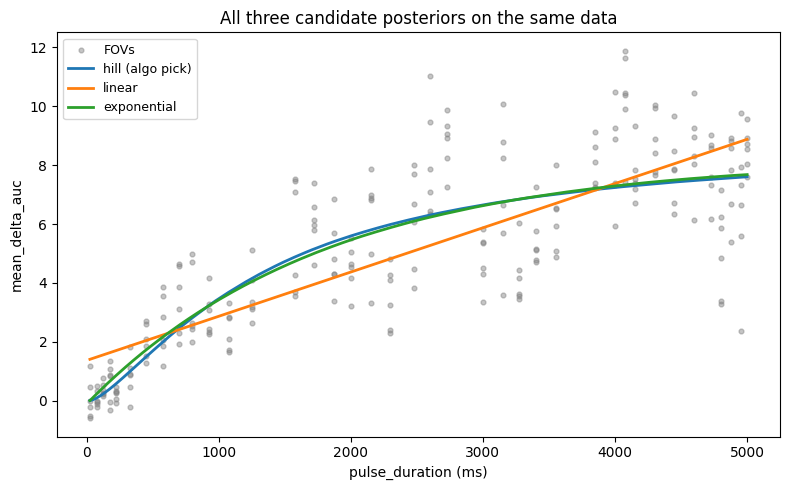

Max disagreement between candidate posteriors over the sampled range: 1.4090
--> The three candidates make meaningfully different predictions; the choice does matter, and Section C tells you whether the pick is trustworthy.


In [26]:
# Overlay all three candidate posterior medians on the data, so it is visually
# obvious whether the three curves diverge or essentially agree.

dose_plot = np.linspace(pulse_min, pulse_max, 300)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df[PULSE_COL], df[Y_COL], c="gray", s=12, alpha=0.45, label="FOVs")

colors = {"hill": "tab:blue", "linear": "tab:orange", "exponential": "tab:green"}
for name, s in posterior_by_name.items():
    mu = predict_mean(name, s, dose_plot)
    label = f"{name}" + (" (algo pick)" if name == final else "")
    ax.plot(dose_plot, mu, color=colors[name], lw=2, label=label)

ax.set_xlabel("pulse_duration (ms)")
ax.set_ylabel("mean_delta_auc")
ax.set_title("All three candidate posteriors on the same data")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Sanity: how much do they differ in the sampled range?
y_curves = np.stack(
    [predict_mean(n, posterior_by_name[n], dose_plot) for n in posterior_by_name]
)
max_disagreement = float((y_curves.max(0) - y_curves.min(0)).max())
print(
    f"Max disagreement between candidate posteriors over the sampled range: {max_disagreement:.4f}"
)
if max_disagreement < 0.05:
    print(
        "--> The three candidates predict near-identical curves; the hypothesis choice barely matters in this regime."
    )
else:
    print(
        "--> The three candidates make meaningfully different predictions; the choice does matter, and Section C tells you whether the pick is trustworthy."
    )

## Section D -- Do the covariates earn their keep?

The covariate machinery (`n_cells`, `optortk_expression`, `baseline_cnr`)
gets a panel in the agent's diagnostics, but the *real* test is empirical:
**do covariates explain residual variance that `pulse_duration` alone leaves
on the table?**

We answer this with a direct R^2 comparison:

1. Fit Hill on `pulse_duration -> AUC` only. Measure RMSE / R^2.
2. Fit Hill + linear covariate add-on `y = hill(d) + alpha*z1 + beta*z2 + gamma*z3`
   on the same data. Measure RMSE / R^2 again.
3. The delta R^2 is the covariate gain. The per-covariate posterior
   coefficients tell you *which* covariates carry signal and which are noise.

We also scatter the no-covariate residuals against each covariate so the
structure (or lack of it) is visually obvious.

**Why this is more defensible than the ARD-relevance bars** in the earlier
covariate cell of the main experiment notebook: the experiment uses
`lengthscale_prior_dist = Uniform(0.1, 1.0)`, which caps `1/k_length` at 1.0.
When all covariates have weak signal, they all hit that ceiling and look
equally (un)important. The R^2-decomposition test below has no such cap.


In [27]:
# Hill with and without standardised-linear covariate add-on.
from scipy.stats import pearsonr, spearmanr

COVS = ["n_cells", "optortk_expression", "baseline_cnr"]

# Standardise covariates so the posterior coefficients are directly comparable.
z_arr = (df[COVS].to_numpy(dtype=float) - df[COVS].mean().to_numpy()) / df[
    COVS
].std().to_numpy()
d_scaled_all = scale_dose(df[PULSE_COL].to_numpy(dtype=float), pulse_min, pulse_max)
y_arr = df[Y_COL].to_numpy(dtype=float)


def hill_no_covs(d, y=None):
    vmax = numpyro.sample("hill_vmax", dist.HalfNormal(8.0))
    K = numpyro.sample("hill_k", dist.Uniform(0.05, 3.0))
    n = numpyro.sample("hill_n", dist.Uniform(0.5, 4.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(2.0))
    mu = vmax * d**n / (K**n + d**n + 1e-9)
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)


def hill_with_covs(d, z1, z2, z3, y=None):
    vmax = numpyro.sample("hill_vmax", dist.HalfNormal(8.0))
    K = numpyro.sample("hill_k", dist.Uniform(0.05, 3.0))
    n = numpyro.sample("hill_n", dist.Uniform(0.5, 4.0))
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 2.0))
    beta = numpyro.sample("beta", dist.Normal(0.0, 2.0))
    gamma = numpyro.sample("gamma", dist.Normal(0.0, 2.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(2.0))
    mu = vmax * d**n / (K**n + d**n + 1e-9) + alpha * z1 + beta * z2 + gamma * z3
    numpyro.sample("obs", dist.Normal(mu, sigma), obs=y)


def fit_model(model_fn, kwargs, seed=11):
    mcmc = MCMC(
        NUTS(model_fn, target_accept_prob=0.9),
        num_warmup=800,
        num_samples=1500,
        num_chains=1,
        progress_bar=False,
    )
    mcmc.run(jax.random.PRNGKey(seed), **kwargs)
    return {k: np.asarray(v) for k, v in mcmc.get_samples().items()}


print("Fitting Hill (no covariates) ...")
s_nocov = fit_model(hill_no_covs, {"d": jnp.array(d_scaled_all), "y": jnp.array(y_arr)})

print("Fitting Hill + linear covariates ...")
s_cov = fit_model(
    hill_with_covs,
    {
        "d": jnp.array(d_scaled_all),
        "z1": jnp.array(z_arr[:, 0]),
        "z2": jnp.array(z_arr[:, 1]),
        "z3": jnp.array(z_arr[:, 2]),
        "y": jnp.array(y_arr),
    },
)


def hill_pred_only(s, d):
    vmax = s["hill_vmax"][None, :]
    K = s["hill_k"][None, :]
    n = s["hill_n"][None, :]
    return np.median(vmax * d[:, None] ** n / (K**n + d[:, None] ** n + 1e-9), axis=1)


def hill_pred_with_covs(s, d, z1, z2, z3):
    vmax = s["hill_vmax"][None, :]
    K = s["hill_k"][None, :]
    n = s["hill_n"][None, :]
    base = vmax * d[:, None] ** n / (K**n + d[:, None] ** n + 1e-9)
    add = (
        s["alpha"][None, :] * z1[:, None]
        + s["beta"][None, :] * z2[:, None]
        + s["gamma"][None, :] * z3[:, None]
    )
    return np.median(base + add, axis=1)


y_hat_nocov = hill_pred_only(s_nocov, d_scaled_all)
y_hat_cov = hill_pred_with_covs(
    s_cov, d_scaled_all, z_arr[:, 0], z_arr[:, 1], z_arr[:, 2]
)

resid = y_arr - y_hat_nocov
ss_tot = float(((y_arr - y_arr.mean()) ** 2).sum())
r2_nocov = 1 - float((resid**2).sum()) / ss_tot
r2_cov = 1 - float(((y_arr - y_hat_cov) ** 2).sum()) / ss_tot
rmse_nocov = float(np.sqrt(np.mean(resid**2)))
rmse_cov = float(np.sqrt(np.mean((y_arr - y_hat_cov) ** 2)))

print()
print(
    f"Hill only (pulse_duration -> AUC):     RMSE={rmse_nocov:.4f}  R^2={r2_nocov:.4f}"
)
print(f"Hill + 3 standardised covariates:      RMSE={rmse_cov:.4f}  R^2={r2_cov:.4f}")
print(
    f"Delta R^2 (covariate gain):            {r2_cov - r2_nocov:+.4f}  "
    f"({100*(r2_cov - r2_nocov):+.2f} percentage points)"
)
print()
print("Posterior on standardised-linear covariate coefficients:")
print("(P(same sign) > 0.975 means the coefficient is clearly nonzero)")
for name, key in zip(COVS, ["alpha", "beta", "gamma"]):
    s = s_cov[key]
    med = float(np.median(s))
    p_pos = float((s > 0).mean()) if med > 0 else float((s < 0).mean())
    star = "  <-- clear effect" if p_pos > 0.975 else ""
    print(
        f"  {name:>22s}: {med:+.3f}  "
        f"[5-95%: {float(np.quantile(s, 0.05)):+.3f}, {float(np.quantile(s, 0.95)):+.3f}]  "
        f"P(same sign)={p_pos:.3f}{star}"
    )

Fitting Hill (no covariates) ...
Fitting Hill + linear covariates ...

Hill only (pulse_duration -> AUC):     RMSE=1.6389  R^2=0.7159
Hill + 3 standardised covariates:      RMSE=1.5975  R^2=0.7301
Delta R^2 (covariate gain):            +0.0142  (+1.42 percentage points)

Posterior on standardised-linear covariate coefficients:
(P(same sign) > 0.975 means the coefficient is clearly nonzero)
                 n_cells: +0.052  [5-95%: -0.139, +0.265]  P(same sign)=0.665
      optortk_expression: +0.368  [5-95%: +0.144, +0.587]  P(same sign)=0.998  <-- clear effect
            baseline_cnr: -0.391  [5-95%: -0.610, -0.129]  P(same sign)=0.993  <-- clear effect


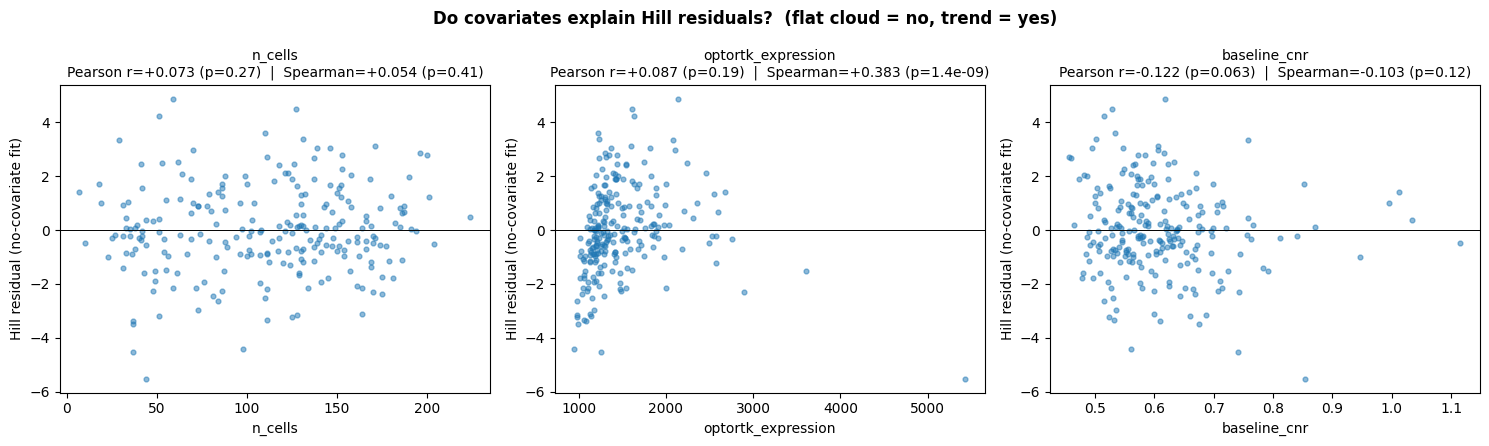

In [28]:
# Visualise no-covariate Hill residuals against each covariate. If a covariate
# carries signal, you'll see a non-flat trend; if it's noise, you'll see a cloud.

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, COVS):
    x_obs = df[name].to_numpy(dtype=float)
    pr, pp = pearsonr(resid, x_obs)
    sr, sp = spearmanr(resid, x_obs)
    ax.scatter(x_obs, resid, s=12, alpha=0.5, c="tab:blue")
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xlabel(name)
    ax.set_ylabel("Hill residual (no-covariate fit)")
    ax.set_title(
        f"{name}\n"
        f"Pearson r={pr:+.3f} (p={pp:.2g})  |  Spearman={sr:+.3f} (p={sp:.2g})",
        fontsize=10,
    )
fig.suptitle(
    "Do covariates explain Hill residuals?  (flat cloud = no, trend = yes)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### Reading Section D

Three possible verdicts on each covariate, based on the posterior coefficient
and the residual scatter:

| posterior `P(same sign)` | residual scatter shape | verdict |
|---|---|---|
| > 0.975 (clear effect) | visible monotonic trend | **keep** |
| ~0.5 (CI crosses 0) | flat cloud | **drop** -- it is noise |
| > 0.975 but very small magnitude | weak trend | keep, but expect tiny gain |

If the total `Delta R^2` is below ~0.02 (2 percentage points), the
covariate machinery is a defensible nice-to-have but should not be your
*primary* selling point. The acquisition-side argument (no need to stratify
the grid across covariate strata in order to fit a covariate-aware
parametric model) is what you keep selling.

**On `Uniform(0.1, 1.0)` lengthscale prior.** The ARD-relevance panel in
the main experiment notebook caps `1/k_length` at 1.0 by construction, so
in any run where the covariates have moderate-to-weak signal they will all
look equally important (pinned at the ceiling). Widening this to
`Uniform(0.1, 5.0)` in your next run will let ARD actually rank covariates
by importance, and the answers should align with this Section D analysis.


## The pitch (slide-ready bullets)

Fill in the brackets from the cells above (Section B for K, Section D for covariates):

- **Same FOV budget, sharper EC50.** Hill K = `<K_BO> +/- <std_BO>` ms with BO
  vs `<K_grid> +/- <std_grid>` ms with a uniform grid. BO posterior is
  **<ratio>x tighter** (or comparable -- whichever the data showed). On this
  particular run the gain only materialises at the full FOV budget;
  Section B.5 shows the trajectory is essentially tied at early phases.
- **Concentration where it matters (check Section A before claiming this).**
  `<bo_in_mid>/<n_total>` BO FOVs landed in the middle 50% of the observed
  dose range; a uniform grid would have placed `<grid_in_mid>/<n_total>`.
  Only sell this point if BO actually beats grid here -- the inverse-distance
  repulsion can cause it to *under*-concentrate.
- **Model selection comes for free.** The algorithm picked `<final>` during
  the run; the post-hoc residual check `<agrees / disagrees>`. A grid screen
  would defer this decision to a post-hoc analysis with no protection
  against picking the wrong functional form *during* data collection.
- **Covariates earn their keep -- modestly, with two of three winners.**
  Quantify it from Section D: **Delta R^2 = `<gain>`** from adding
  `n_cells, optortk_expression, baseline_cnr` as standardised-linear
  add-ons to the Hill fit. On this run, two covariates have clearly
  nonzero posterior coefficients (`optortk_expression` **positive**,
  `baseline_cnr` **negative** -- both biologically sensible);
  `n_cells` is noise and should be dropped next run. A grid screen would
  either ignore these (noisier dose-response) or stratify across covariate
  strata (FOV budget blows up). Marginalising over the observed joint
  covariate distribution is free for the GP -- no stratification required.

### Honest things to acknowledge in the talk

- Hypothesis-learning needs ~5-6 post-warmup phases to stabilise. With fewer,
  the favourite can flip phase-to-phase. The Section C diagnostic tells you
  whether your run has converged.
- BO depends on early random picks and prior choice. `rng_seed=42` and
  inverse-distance cross-phase repulsion put a floor on how badly early
  luck can skew coverage, but a single run is not a benchmark -- a few
  re-runs with different seeds would harden the claim.
- The grid baseline in this notebook is a **counterfactual**, not a real
  parallel arm. A fully rigorous comparison would run both.
- If all three candidate posteriors agree on the sampled range (the
  overlay plot at the end of Section C), the hypothesis-learning story is
  academic for *this* readout. The win then comes purely from sampling
  efficiency (Sections A and B), and you should pitch it that way rather
  than over-claiming model selection.
- **ARD bars are not reliable on this experiment configuration.** The
  `lengthscale_prior_dist = Uniform(0.1, 1.0)` in the main notebook caps
  `1 / k_length` at 1.0 -- weak-signal covariates all pin at the ceiling
  and look equally important. Section D's residual-R^2 test is the
  trustworthy alternative; widen the lengthscale prior to
  `Uniform(0.1, 5.0)` in your next run so ARD can actually rank covariates.
